In [ ]:
%load_ext autoreload
%autoreload 2

# Importing the modules

import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
# from solver_2DHcurl_1DH1_Copie import *
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

import Antenna_Desc_n_Plot as antenna

geom_mode = "1D" # "1D" or "2D" 
box_medium = "VACUUM" # "VACUUM" or "PLASMA" 

antenna_grill = None
if antenna_grill != None:
    antenna_grill = antenna.AntennaGrill(b_active=0.009, d_septa=0.002, d_gap=0.010)
    antenna_grill.add_module(num_active=10, delta_phi_deg=90, is_PAM=False)

    instructions = antenna_grill.generate_mesh_instructions()
    antenna.plot_antenna_blueprint(instructions)

solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, geom_mode, box_medium, antenna_grill)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
n_e = 0.00e+00 m^-3
In LHCoupling class: n_para: 0.0, n_perp_p: 1.00e+00+0.00e+00j, n_perp_m: 1.00e+00+0.00e+00j


In [7]:
mesh = solver.build_mesh_with_PMLs()
solver.build_physics_Stix_B_field()

GF_E_field, Gamma_R, Gamma_T, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, geom_mode, box_medium)

geom_mode: 2D
box_medium: VACUUM
==== 
Lx_plasma: 2.00e-01m,   Lx_pml: 1.00e-02m,    Lx_tot: 2.10e-01m
Lx_wg = 0.00e+00m
Lz_antenna: 0.00e+00m, Lz_wall: 0.00e+00m
Lz_plasma: 1.50e-01m, Lz_pml: 7.50e-02m, Lz_tot: 3.00e-01m
==== 
n_∥: 0.0,   λ_∥: 8.10e+04m 
n_⟂⁺:1.00+0.00j, λ_⟂⁺: 8.10e-02m 
n_⟂-:1.00+0.00j, λ_⟂⁻: 8.10e-02m
==== 
n_index_meshing: 1.00 
λ_meshing: 8.10e-02m 
maxh_plasma: 5.40e-03m
==== 
Lz_wall: 0.00e+00m 
Lz_source: 1.50e-01m
==== 
PPW_pml: 50.0 
Sx_norm:5.85e+00, maxh_pml_radial: 2.77e-04 
Sz_norm_max: 6.40e+00, maxh_pml_toroidal: 2.53e-04 
maxh_pml_corner: 1.87e-04
[DOMAIN 2D DEFINED AND GLUED]
[MESH GENERATED !]
==== 
#DoFs = 629312
--- Solving the 3D vector linear system ---
==== 
w_size_R: 1.2154e-01m,    w_size_T: 7.5000e-02m
Gamma_R (SWR) = 2.456e-01
Gamma_T (SWR) = 7.935e-02
==== 
Net Power Flow (W/m) => P_in: 1.8550e-02 | P_out_top: 1.5158e-02 
P_out_right: 1.6439e-03 | P_out_T_left: 1.6439e-03
type(P_ideal): <class 'numpy.float64'>
Sx_val: 1.3272e-01 W/m^2
(Lz_s

In [8]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
# run_folder_tot_path = "/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/" + run_folder_path
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260623_152709
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260623_152709


--- Extracting 2D Wave Map ---
Lz_plasma_src: 0.150, Lz_wall: 0.000, Lz_pml: 0.075, Lz_tot: 0.300
Bornes géométriques fixées
  --> Pure Multithreaded C++ vectorized interpolation...
n_e = 0.00e+00 m^-3
In LHCoupling class: n_para: 0.0, n_perp_p: 1.00e+00+0.00e+00j, n_perp_m: 1.00e+00+0.00e+00j
n_e = 0.00e+00 m^-3
PP_run_n_save: n_para: 0.0, n_perp_p: 1.00e+00+0.00e+00j, n_perp_m: 1.00e+00+0.00e+00j
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260623_152709/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui

PRINT H5 METADATA:
 Lx_plasma: 2.00e-01
 Lx_pml: 1.00e-02
 Lx_tot: 2.10e-01
 Lz_plasma: 1.50e-01
 Lz_pml: 7.50e-02
 Lz_tot: 3.00e-01
 P_ideal: 1.39e-02
 P_in_net: 1.85e-02
 P_out_R: 1.52e-02
 P_out_T_left: 1.64e-03
 P_out_T_right: 1.64e-03
 eta_pred_R: 2.44e-01
 eta_pred_T: 1.00e+00
 eta_sim_R: 2.46e-01
 eta_sim_T: 7.94e-02
 k_para: -0.00e+00
 k_perp_p: (-77.54626581221223+0j)
 lambda_perp_real: 8.10e-02
 n_para: 0.00e+00

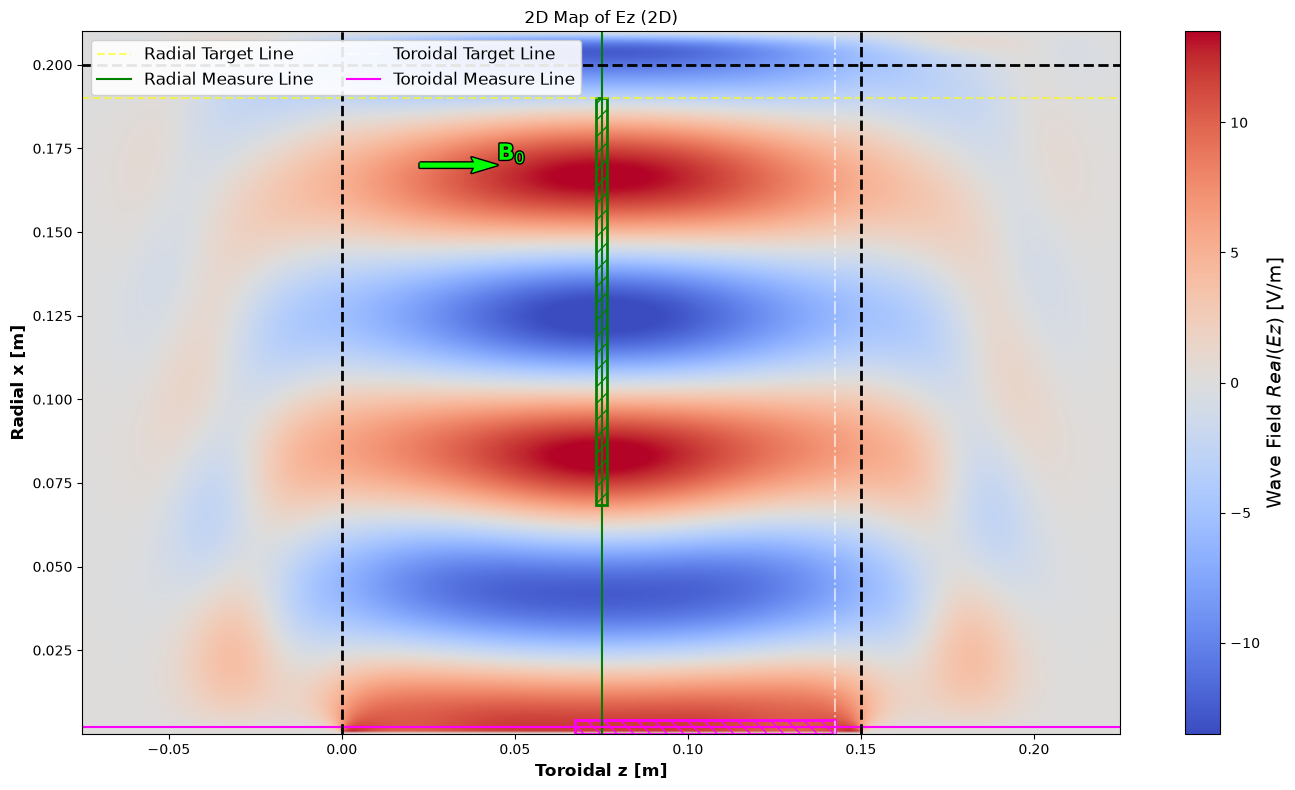

In [9]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, geom_mode, box_medium, antenna_grill, diag_data)
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 
# Plot E field 2D map and save it in the same folder: Run_XXX 
Lx_wg = cfg.DOMAIN.get('Lx_wg', 0.03)
Lz_wall = cfg.DOMAIN.get('Lz_wall', 0.02)

pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, geom_mode, component='Ez', value_type='real',
                         antenna_grill=antenna_grill, Lx_wg=Lx_wg, Lz_wall=Lz_wall, plot_poynting=False, show_windows=True, Poynting_box=False)

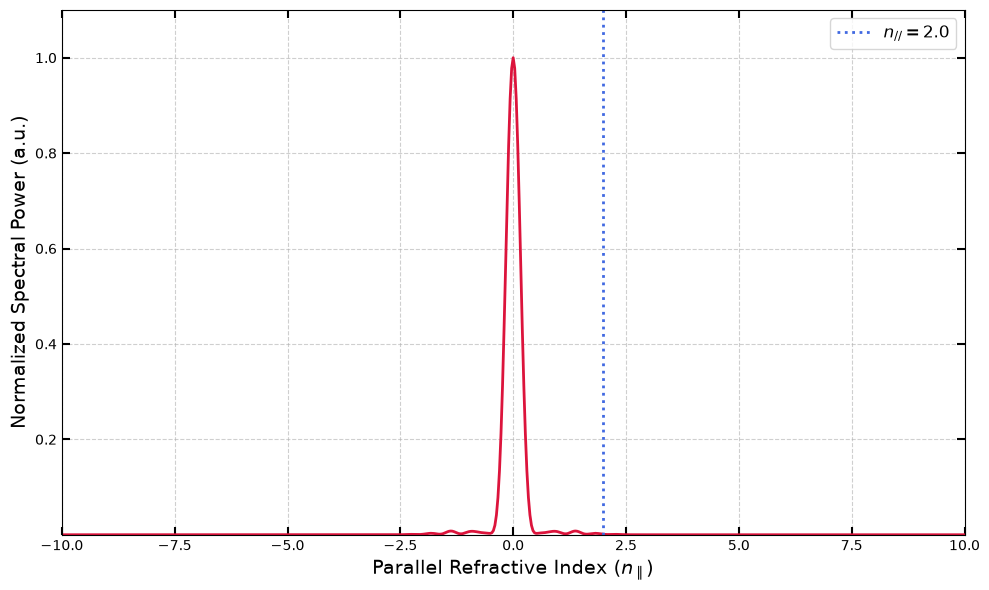

In [10]:
# Test n_para spectrum

n_para_array, power_spectrum = pp_plot.plot_n_para_spectrum(mesh, GF_E_field, cfg, geom_mode, x_eval=0.015)
